In [130]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

In [131]:
df = pd.read_csv(
    "../data/processed/feature_engineered_data.csv"
)

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (120000, 61)


,admission_id,patient_id,hospital_id,admit_type,ward_type,los_days,readmitted_30d,age,gender,patient_state,...,age_cost,diagnosis_cost,teaching_long_stay,has_cardiovascular,has_respiratory,has_neurological,has_endocrine,has_infectious,has_neoplasm,has_gastrointestinal
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Elective,General,4,0,46,M,Haryana,...,850632,18492,0,0,0,0,1,0,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,8b1e01b7-9f0e-413f-b330-454d271a5c6e,OPD,General,1,0,31,M,Andhra Pradesh,...,31031,1001,0,0,1,0,0,0,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Emergency,General,5,1,53,F,West Bengal,...,3163888,179088,0,1,0,1,0,1,0,0
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,df4431ea-1acf-4e77-963c-6173e9787151,Emergency,ICU,11,1,56,F,Kerala,...,4064928,72588,0,1,0,0,0,0,0,0
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Emergency,General,5,1,69,F,Kerala,...,656190,28530,0,0,1,0,0,0,1,1


In [132]:
print(df.columns.tolist())

['admission_id', 'patient_id', 'hospital_id', 'admit_type', 'ward_type', 'los_days', 'readmitted_30d', 'age', 'gender', 'patient_state', 'insurance_type', 'hospital_name', 'hospital_state', 'hospital_tier', 'beds', 'teaching', 'primary_diagnosis', 'primary_diag_category', 'total_diagnoses', 'diagnosis_list', 'diagnosis_categories', 'cost_category', 'total_cost_inr', 'admit_year', 'admit_month', 'admit_day', 'admit_weekday', 'admit_quarter', 'discharge_year', 'discharge_month', 'weekend_admission', 'stay_per_bed', 'cost_per_day', 'cost_per_bed', 'num_diagnosis_categories', 'diagnosis_density', 'cost_per_diagnosis', 'diagnosis_per_bed', 'elderly', 'very_elderly', 'long_stay', 'very_long_stay', 'multiple_diagnoses', 'age_diagnosis', 'large_hospital', 'low_cost', 'high_cost', 'bed_cost_ratio', 'bed_los_ratio', 'season', 'age_los', 'age_cost', 'diagnosis_cost', 'teaching_long_stay', 'has_cardiovascular', 'has_respiratory', 'has_neurological', 'has_endocrine', 'has_infectious', 'has_neoplasm

In [133]:
print(df.info())

print("\n")

print(df.describe())

print("\n")

print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 61 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   admission_id              120000 non-null  str    
 1   patient_id                120000 non-null  str    
 2   hospital_id               120000 non-null  str    
 3   admit_type                120000 non-null  str    
 4   ward_type                 120000 non-null  str    
 5   los_days                  120000 non-null  int64  
 6   readmitted_30d            120000 non-null  int64  
 7   age                       120000 non-null  int64  
 8   gender                    120000 non-null  str    
 9   patient_state             120000 non-null  str    
 10  insurance_type            120000 non-null  str    
 11  hospital_name             120000 non-null  str    
 12  hospital_state            120000 non-null  str    
 13  hospital_tier             120000 non-null  str    
 14 

In [134]:
database_path = "../database/healthops.db"

Path("../database").mkdir(
    exist_ok=True
)

connection = sqlite3.connect(database_path)

print("Database Created Successfully.")

Database Created Successfully.


In [135]:
df.to_sql(
    "hospital_data",
    connection,
    if_exists="replace",
    index=False
)

print("Dataset Exported Successfully.")

Dataset Exported Successfully.


In [136]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql_query(
    query,
    connection
)

tables

,name
0,hospital_data


In [137]:
query = """
SELECT *
FROM hospital_data
LIMIT 10;
"""

preview = pd.read_sql_query(
    query,
    connection
)

preview

,admission_id,patient_id,hospital_id,admit_type,ward_type,los_days,readmitted_30d,age,gender,patient_state,...,age_cost,diagnosis_cost,teaching_long_stay,has_cardiovascular,has_respiratory,has_neurological,has_endocrine,has_infectious,has_neoplasm,has_gastrointestinal
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Elective,General,4,0,46,M,Haryana,...,850632,18492,0,0,0,0,1,0,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,8b1e01b7-9f0e-413f-b330-454d271a5c6e,OPD,General,1,0,31,M,Andhra Pradesh,...,31031,1001,0,0,1,0,0,0,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Emergency,General,5,1,53,F,West Bengal,...,3163888,179088,0,1,0,1,0,1,0,0
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,df4431ea-1acf-4e77-963c-6173e9787151,Emergency,ICU,11,1,56,F,Kerala,...,4064928,72588,0,1,0,0,0,0,0,0
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Emergency,General,5,1,69,F,Kerala,...,656190,28530,0,0,1,0,0,0,1,1
5,bc3126ac-43ae-4b24-8063-87221bace775,bf89460d-6cb4-4ff3-b4fb-610f0401c533,ec4cfe51-9dc6-4c37-aa71-6a806ad081a7,Emergency,HDU,6,0,37,M,Uttar Pradesh,...,2808633,75909,0,0,0,0,0,0,0,0
6,2e429763-fbfe-40dd-9f99-e94a8bb71dc5,c32463a0-ee55-4838-8574-5152caee0ba1,0b90b010-a4b9-443f-a2ca-58033973fc14,Emergency,ICU,24,0,48,M,Maharashtra,...,62485056,1301772,1,0,0,0,0,1,0,0
7,1e6d5dd7-bb7c-4bc7-a54f-d967d88445e3,99f978de-8381-49eb-8279-4d64d77cc889,a86650ea-3517-4285-bc11-ffa2085a8df2,Emergency,General,2,0,57,F,Andhra Pradesh,...,126597,2221,0,0,0,0,1,0,0,0
8,bfa54669-eb78-4fc2-ab15-0d9298c626cd,e836160b-cd34-4e0e-a7e2-621b627fdc05,28879338-cd09-48bb-bedb-730b8ee8ab4e,Emergency,General,4,0,49,M,West Bengal,...,1441727,88269,0,1,0,0,0,0,0,1
9,b1553698-9045-4f6b-a369-708600d6d1d9,0fbd3497-3e52-4ffb-9daa-58516afcae2e,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Elective,HDU,2,0,66,M,West Bengal,...,570636,34584,0,1,1,0,1,0,0,0


In [138]:
query = """
SELECT

    COUNT(*) AS Total_Admissions,

    COUNT(DISTINCT patient_id) AS Total_Patients,

    COUNT(DISTINCT hospital_id) AS Total_Hospitals,

    ROUND(AVG(age),2) AS Average_Age,

    ROUND(AVG(los_days),2) AS Average_Length_of_Stay,

    ROUND(AVG(total_cost_inr),2) AS Average_Treatment_Cost,

    ROUND(SUM(total_cost_inr),2) AS Total_Revenue,

    ROUND(
        AVG(readmitted_30d) * 100,
        2
    ) AS Readmission_Rate

FROM hospital_data;
"""

kpi_dashboard = pd.read_sql_query(
    query,
    connection
)

kpi_dashboard

,Total_Admissions,Total_Patients,Total_Hospitals,Average_Age,Average_Length_of_Stay,Average_Treatment_Cost,Total_Revenue,Readmission_Rate
0,120000,64873,33,48.05,6.85,95779.53,1.149354e+10,11.84


In [139]:
kpis = kpi_dashboard.iloc[0]

print("        HEALTHOPS AI - EXECUTIVE KPI DASHBOARD")
print(f"Total Admissions       : {int(kpis['Total_Admissions']):,}")

print(f"Total Patients         : {int(kpis['Total_Patients']):,}")

print(f"Total Hospitals        : {int(kpis['Total_Hospitals']):,}")

print(f"Average Age            : {kpis['Average_Age']:.2f} years")

print(f"Average LOS            : {kpis['Average_Length_of_Stay']:.2f} days")

print(f"Average Treatment Cost : ₹{kpis['Average_Treatment_Cost']:,.2f}")

print(f"Total Revenue          : ₹{kpis['Total_Revenue']:,.2f}")

print(f"Readmission Rate       : {kpis['Readmission_Rate']:.2f}%")


        HEALTHOPS AI - EXECUTIVE KPI DASHBOARD
Total Admissions       : 120,000
Total Patients         : 64,873
Total Hospitals        : 33
Average Age            : 48.05 years
Average LOS            : 6.85 days
Average Treatment Cost : ₹95,779.53
Total Revenue          : ₹11,493,543,798.00
Readmission Rate       : 11.84%


In [140]:
Path("../powerbi").mkdir(
    exist_ok=True
)

kpi_dashboard.to_csv(
    "../powerbi/hospital_kpis.csv",
    index=False
)

print("Executive KPI table exported successfully.")

Executive KPI table exported successfully.


In [141]:
query = """
SELECT

    hospital_name,

    ROUND(
        SUM(total_cost_inr),
        2
    ) AS Total_Revenue,

    COUNT(*) AS Total_Admissions,

    ROUND(
        AVG(total_cost_inr),
        2
    ) AS Average_Treatment_Cost

FROM hospital_data

GROUP BY hospital_name

ORDER BY Total_Revenue DESC;
"""

hospital_revenue = pd.read_sql_query(
    query,
    connection
)

hospital_revenue

,hospital_name,Total_Revenue,Total_Admissions,Average_Treatment_Cost
0,Apollo/Manipal (Private) Andhra Pradesh,3.182935e+09,14497,219558.16
1,Apollo/Manipal (Private) Karnataka,1.626266e+09,7245,224467.35
2,Apollo/Manipal (Private) Telangana,8.157342e+08,3720,219283.38
3,Apollo/Manipal (Private) Uttar Pradesh,7.753105e+08,3565,217478.40
4,Government General Hospital Tamil Nadu,2.837629e+08,3660,77530.83
5,Government General Hospital Karnataka,2.792076e+08,3653,76432.41
6,Government General Hospital Haryana,2.783468e+08,3650,76259.39
7,Government General Hospital Punjab,2.759942e+08,3612,76410.35
8,Government General Hospital West Bengal,2.749059e+08,3621,75919.89
9,Government General Hospital Uttar Pradesh,2.746511e+08,3640,75453.59


In [142]:
top10_hospitals = hospital_revenue.head(10)

top10_hospitals

,hospital_name,Total_Revenue,Total_Admissions,Average_Treatment_Cost
0,Apollo/Manipal (Private) Andhra Pradesh,3.182935e+09,14497,219558.16
1,Apollo/Manipal (Private) Karnataka,1.626266e+09,7245,224467.35
2,Apollo/Manipal (Private) Telangana,8.157342e+08,3720,219283.38
3,Apollo/Manipal (Private) Uttar Pradesh,7.753105e+08,3565,217478.40
4,Government General Hospital Tamil Nadu,2.837629e+08,3660,77530.83
5,Government General Hospital Karnataka,2.792076e+08,3653,76432.41
6,Government General Hospital Haryana,2.783468e+08,3650,76259.39
7,Government General Hospital Punjab,2.759942e+08,3612,76410.35
8,Government General Hospital West Bengal,2.749059e+08,3621,75919.89
9,Government General Hospital Uttar Pradesh,2.746511e+08,3640,75453.59


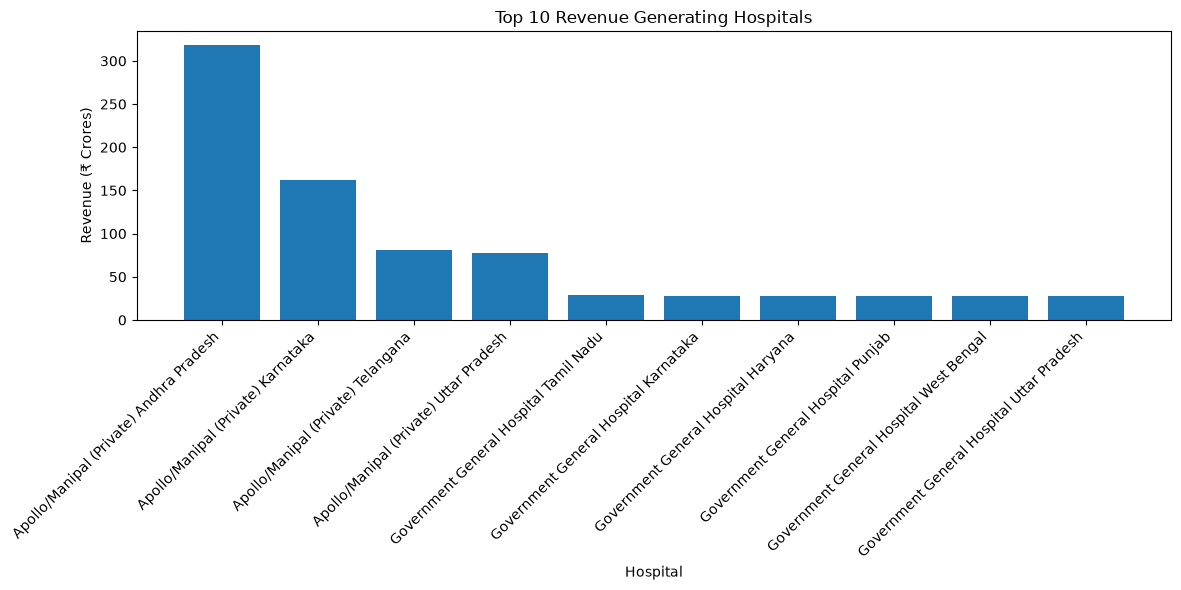

In [143]:
plt.figure(figsize=(12,6))

plt.bar(
    top10_hospitals["hospital_name"],
    top10_hospitals["Total_Revenue"] / 1e7
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Hospital")

plt.ylabel("Revenue (₹ Crores)")

plt.title("Top 10 Revenue Generating Hospitals")

plt.tight_layout()

plt.show()

In [144]:
hospital_revenue.to_csv(
    "../powerbi/revenue_by_hospital.csv",
    index=False
)

print("Revenue by Hospital exported successfully.")

Revenue by Hospital exported successfully.


In [145]:
query = """
SELECT

    hospital_state,

    ROUND(
        SUM(total_cost_inr),
        2
    ) AS Total_Revenue,

    COUNT(*) AS Total_Admissions,

    ROUND(
        AVG(total_cost_inr),
        2
    ) AS Average_Treatment_Cost

FROM hospital_data

GROUP BY hospital_state

ORDER BY Total_Revenue DESC;
"""

state_revenue = pd.read_sql_query(
    query,
    connection
)

state_revenue

,hospital_state,Total_Revenue,Total_Admissions,Average_Treatment_Cost
0,Andhra Pradesh,3.454567e+09,18100,190860.08
1,Karnataka,1.905474e+09,10898,174846.17
2,Uttar Pradesh,1.252878e+09,14574,85966.65
3,Telangana,1.078336e+09,7421,145308.76
4,Bihar,4.767047e+08,11104,42930.89
5,Odisha,4.581211e+08,10788,42465.81
6,Kerala,3.774703e+08,7198,52441.00
7,Gujarat,3.710318e+08,7227,51339.67
8,Madhya Pradesh,3.672836e+08,7195,51047.05
9,Rajasthan,3.647609e+08,7260,50242.55


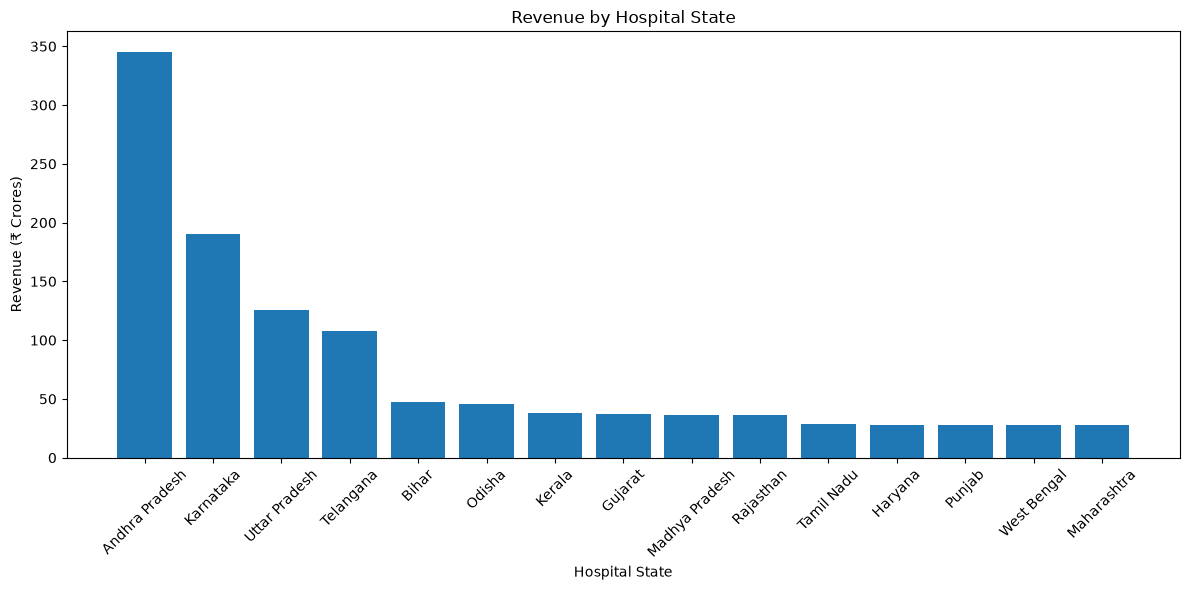

In [146]:
plt.figure(figsize=(12,6))

plt.bar(
    state_revenue["hospital_state"],
    state_revenue["Total_Revenue"] / 1e7
)

plt.xticks(rotation=45)

plt.xlabel("Hospital State")

plt.ylabel("Revenue (₹ Crores)")

plt.title("Revenue by Hospital State")

plt.tight_layout()

plt.show()

In [147]:
state_revenue.to_csv(
    "../powerbi/revenue_by_state.csv",
    index=False
)

print("Revenue by State exported successfully.")

Revenue by State exported successfully.


In [148]:
query = """
SELECT

    insurance_type,

    ROUND(
        SUM(total_cost_inr),
        2
    ) AS Total_Revenue,

    COUNT(*) AS Total_Admissions,

    ROUND(
        AVG(total_cost_inr),
        2
    ) AS Average_Treatment_Cost

FROM hospital_data

GROUP BY insurance_type

ORDER BY Total_Revenue DESC;
"""

insurance_revenue = pd.read_sql_query(
    query,
    connection
)

insurance_revenue

,insurance_type,Total_Revenue,Total_Admissions,Average_Treatment_Cost
0,Ayushman,3.491087e+09,36264,96268.67
1,Unknown,3.167914e+09,33987,93209.58
2,Private,2.920870e+09,29908,97661.83
3,ESI,1.913673e+09,19841,96450.42


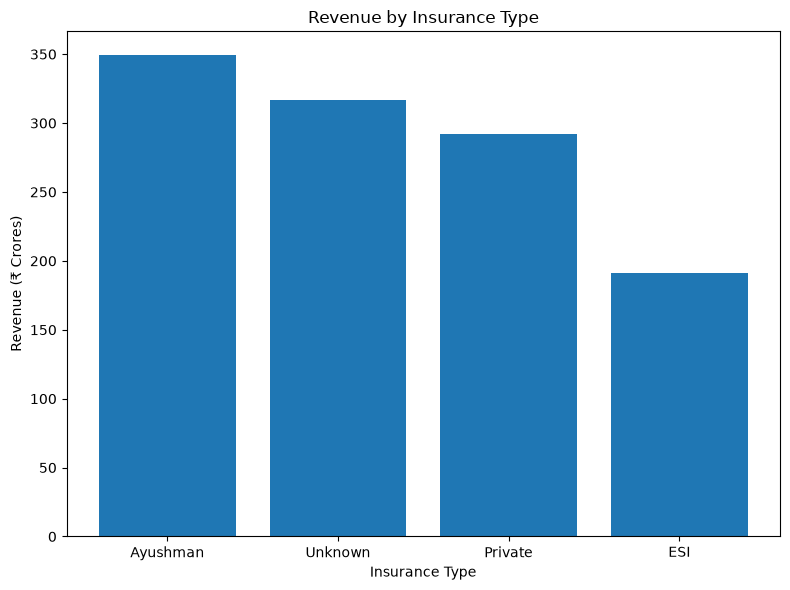

In [149]:
plt.figure(figsize=(8,6))

plt.bar(
    insurance_revenue["insurance_type"],
    insurance_revenue["Total_Revenue"] / 1e7
)

plt.xlabel("Insurance Type")

plt.ylabel("Revenue (₹ Crores)")

plt.title("Revenue by Insurance Type")

plt.tight_layout()

plt.show()

In [150]:
insurance_revenue.to_csv(
    "../powerbi/revenue_by_insurance.csv",
    index=False
)

print("Revenue by Insurance exported successfully.")

Revenue by Insurance exported successfully.


In [151]:
query = """
SELECT

    hospital_tier,

    ROUND(
        SUM(total_cost_inr),
        2
    ) AS Total_Revenue,

    COUNT(*) AS Total_Admissions,

    ROUND(
        AVG(total_cost_inr),
        2
    ) AS Average_Treatment_Cost

FROM hospital_data

GROUP BY hospital_tier

ORDER BY Total_Revenue DESC;
"""

tier_revenue = pd.read_sql_query(
    query,
    connection
)

tier_revenue

,hospital_tier,Total_Revenue,Total_Admissions,Average_Treatment_Cost
0,tier1,6.400245e+09,29027,220492.83
1,tier2,4.072808e+09,54505,74723.57
2,tier3,1.020491e+09,36468,27983.18


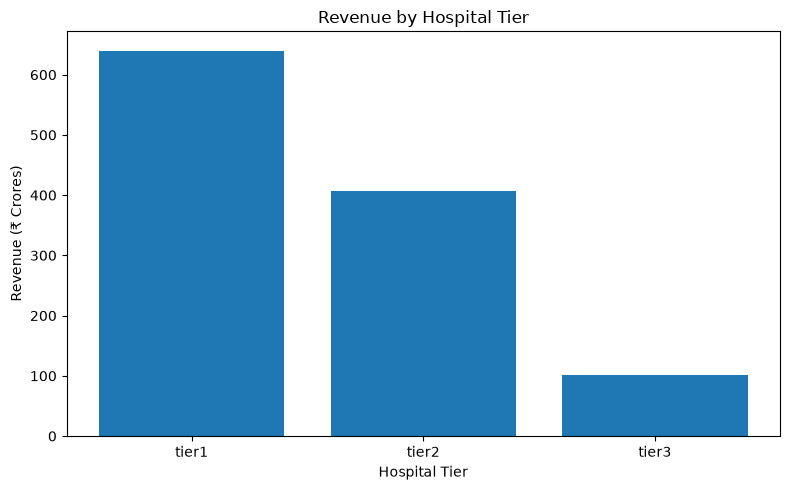

In [152]:
plt.figure(figsize=(8,5))

plt.bar(
    tier_revenue["hospital_tier"].astype(str),
    tier_revenue["Total_Revenue"] / 1e7
)

plt.xlabel("Hospital Tier")

plt.ylabel("Revenue (₹ Crores)")

plt.title("Revenue by Hospital Tier")

plt.tight_layout()

plt.show()

In [153]:
tier_revenue.to_csv(
    "../powerbi/revenue_by_hospital_tier.csv",
    index=False
)

print("Revenue by Hospital Tier exported successfully.")

Revenue by Hospital Tier exported successfully.


In [154]:
query = """
SELECT

    ward_type,

    ROUND(
        SUM(total_cost_inr),
        2
    ) AS Total_Revenue,

    COUNT(*) AS Total_Admissions,

    ROUND(
        AVG(total_cost_inr),
        2
    ) AS Average_Treatment_Cost

FROM hospital_data

GROUP BY ward_type

ORDER BY Total_Revenue DESC;
"""

ward_revenue = pd.read_sql_query(
    query,
    connection
)

ward_revenue

,ward_type,Total_Revenue,Total_Admissions,Average_Treatment_Cost
0,ICU,6.571817e+09,20833,315452.28
1,General,2.292346e+09,76768,29860.70
2,HDU,1.397772e+09,15907,87871.51
3,NICU,1.231608e+09,6492,189711.61


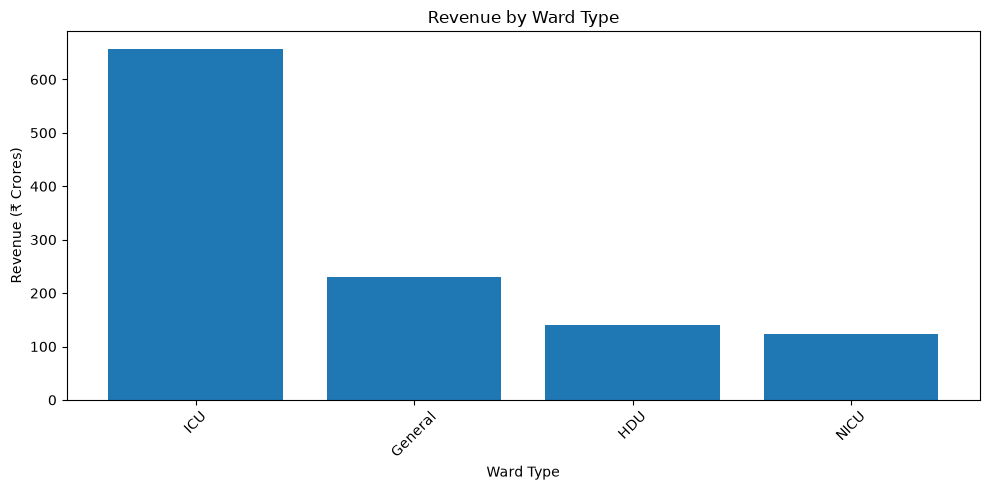

In [155]:
plt.figure(figsize=(10,5))

plt.bar(
    ward_revenue["ward_type"],
    ward_revenue["Total_Revenue"] / 1e7
)

plt.xticks(rotation=45)

plt.xlabel("Ward Type")

plt.ylabel("Revenue (₹ Crores)")

plt.title("Revenue by Ward Type")

plt.tight_layout()

plt.show()

In [156]:
ward_revenue.to_csv(
    "../powerbi/revenue_by_ward.csv",
    index=False
)

print("Revenue by Ward exported successfully.")

Revenue by Ward exported successfully.


In [157]:
query = """
SELECT

    primary_diag_category,

    ROUND(
        SUM(total_cost_inr),
        2
    ) AS Total_Revenue,

    COUNT(*) AS Total_Admissions,

    ROUND(
        AVG(total_cost_inr),
        2
    ) AS Average_Treatment_Cost

FROM hospital_data

GROUP BY primary_diag_category

ORDER BY Total_Revenue DESC;
"""

diagnosis_revenue = pd.read_sql_query(
    query,
    connection
)

diagnosis_revenue

,primary_diag_category,Total_Revenue,Total_Admissions,Average_Treatment_Cost
0,Cardiovascular,4.351349e+09,23964,181578.58
1,Respiratory,1.760593e+09,12420,141754.67
2,Infectious,1.210095e+09,13334,90752.57
3,Perinatal,1.137353e+09,5358,212271.93
4,Injury,8.018169e+08,7269,110306.36
5,Endocrine,5.197213e+08,16877,30794.65
6,Genitourinary,4.913468e+08,7168,68547.27
7,Gastrointestinal,4.558643e+08,11007,41415.86
8,Neoplasm,4.462919e+08,8524,52357.10
9,Neurological,2.230601e+08,7841,28447.92


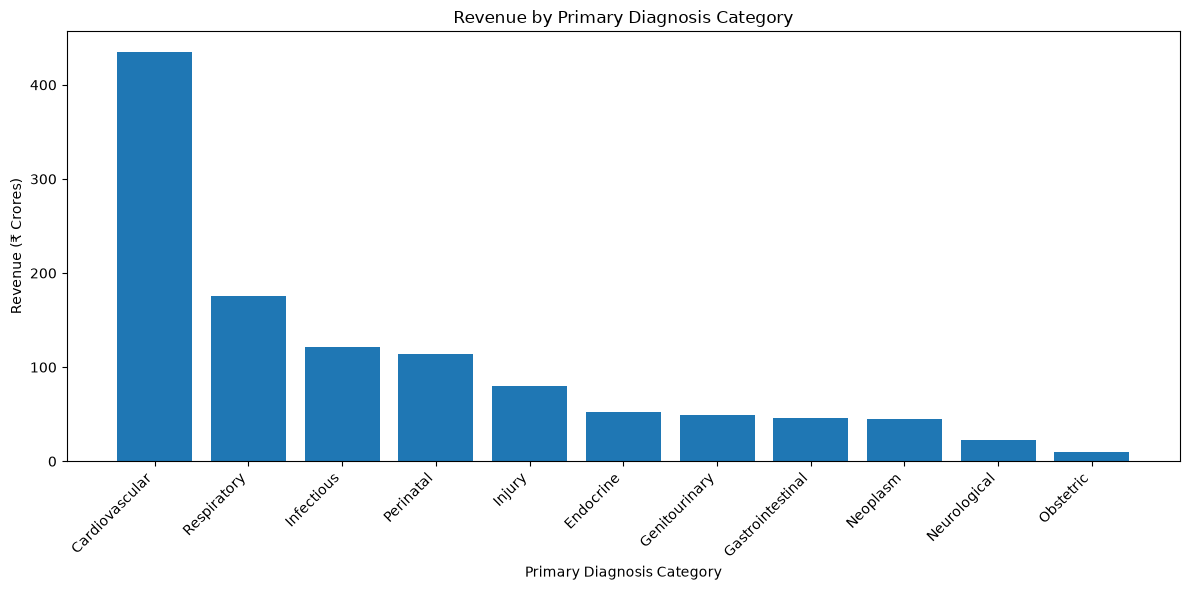

In [158]:
plt.figure(figsize=(12,6))

plt.bar(
    diagnosis_revenue["primary_diag_category"],
    diagnosis_revenue["Total_Revenue"] / 1e7
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Primary Diagnosis Category")

plt.ylabel("Revenue (₹ Crores)")

plt.title("Revenue by Primary Diagnosis Category")

plt.tight_layout()

plt.show()

In [159]:
diagnosis_revenue.to_csv(
    "../powerbi/revenue_by_diagnosis.csv",
    index=False
)

print("Revenue by Diagnosis Category exported successfully.")

Revenue by Diagnosis Category exported successfully.


In [160]:
query = """
SELECT

    cost_category,

    ROUND(
        SUM(total_cost_inr),
        2
    ) AS Total_Revenue,

    COUNT(*) AS Total_Admissions,

    ROUND(
        AVG(total_cost_inr),
        2
    ) AS Average_Treatment_Cost

FROM hospital_data

GROUP BY cost_category

ORDER BY Total_Revenue DESC;
"""

cost_revenue = pd.read_sql_query(
    query,
    connection
)

cost_revenue

,cost_category,Total_Revenue,Total_Admissions,Average_Treatment_Cost
0,Pharmacy,3.470293e+09,36280,95653.06
1,Procedure,3.210224e+09,33536,95724.71
2,Room,2.893526e+09,29988,96489.45
3,Lab,1.919501e+09,20196,95043.64


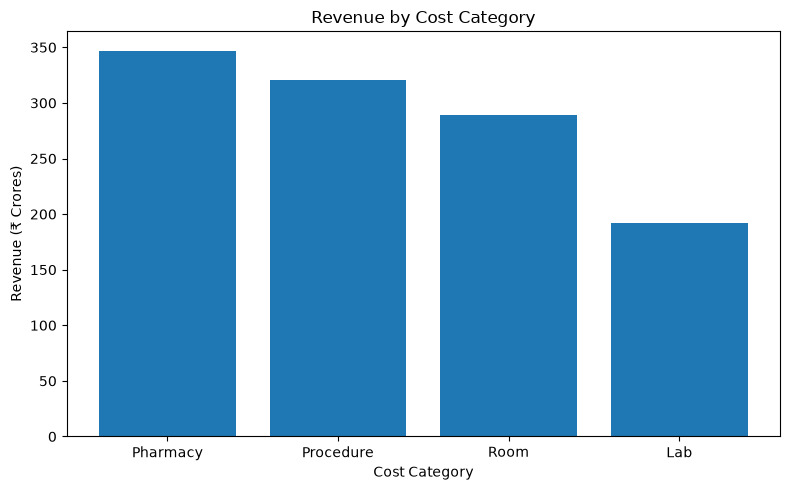

In [161]:
plt.figure(figsize=(8,5))

plt.bar(
    cost_revenue["cost_category"],
    cost_revenue["Total_Revenue"] / 1e7
)

plt.xlabel("Cost Category")

plt.ylabel("Revenue (₹ Crores)")

plt.title("Revenue by Cost Category")

plt.tight_layout()

plt.show()

In [162]:
cost_revenue.to_csv(
    "../powerbi/revenue_by_cost_category.csv",
    index=False
)

print("Revenue by Cost Category exported successfully.")

Revenue by Cost Category exported successfully.


In [163]:
query = """
SELECT

    admit_month,

    ROUND(
        SUM(total_cost_inr),
        2
    ) AS Total_Revenue,

    COUNT(*) AS Total_Admissions,

    ROUND(
        AVG(total_cost_inr),
        2
    ) AS Average_Treatment_Cost

FROM hospital_data

GROUP BY admit_month

ORDER BY admit_month;
"""

monthly_revenue = pd.read_sql_query(
    query,
    connection
)

monthly_revenue

,admit_month,Total_Revenue,Total_Admissions,Average_Treatment_Cost
0,1,950380054.0,10126,93855.43
1,2,882186452.0,9250,95371.51
2,3,992358326.0,10180,97481.17
3,4,986417866.0,9992,98720.76
4,5,937896147.0,10155,92358.06
5,6,935801949.0,9894,94582.77
6,7,978110372.0,10235,95565.25
7,8,982662880.0,10159,96728.31
8,9,936140993.0,9795,95573.35
9,10,961393132.0,10173,94504.39


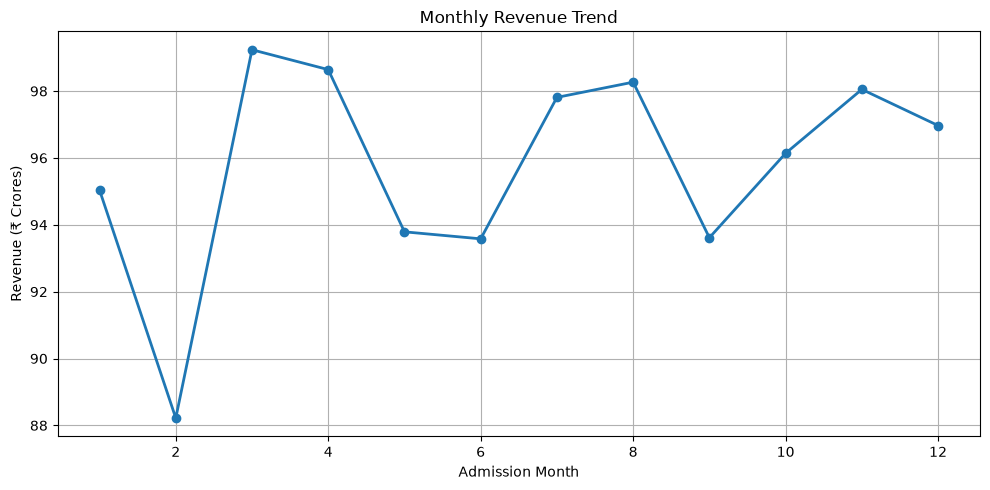

In [164]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue["admit_month"],
    monthly_revenue["Total_Revenue"] / 1e7,
    marker="o",
    linewidth=2
)

plt.xlabel("Admission Month")

plt.ylabel("Revenue (₹ Crores)")

plt.title("Monthly Revenue Trend")

plt.grid(True)

plt.tight_layout()

plt.show()

In [165]:
monthly_revenue.to_csv(
    "../powerbi/monthly_revenue.csv",
    index=False
)

print("Monthly Revenue Trend exported successfully.")

Monthly Revenue Trend exported successfully.


In [166]:
query = """
SELECT

    primary_diag_category,

    COUNT(*) AS Total_Admissions,

    SUM(readmitted_30d) AS Readmitted_Patients,

    ROUND(
        AVG(readmitted_30d) * 100,
        2
    ) AS Readmission_Rate

FROM hospital_data

GROUP BY primary_diag_category

ORDER BY Readmission_Rate DESC;
"""

diagnosis_readmission = pd.read_sql_query(
    query,
    connection
)

diagnosis_readmission

,primary_diag_category,Total_Admissions,Readmitted_Patients,Readmission_Rate
0,Perinatal,5358,998,18.63
1,Cardiovascular,23964,3973,16.58
2,Respiratory,12420,2006,16.15
3,Genitourinary,7168,914,12.75
4,Neoplasm,8524,1046,12.27
5,Injury,7269,786,10.81
6,Infectious,13334,1293,9.70
7,Endocrine,16877,1576,9.34
8,Gastrointestinal,11007,799,7.26
9,Neurological,7841,568,7.24


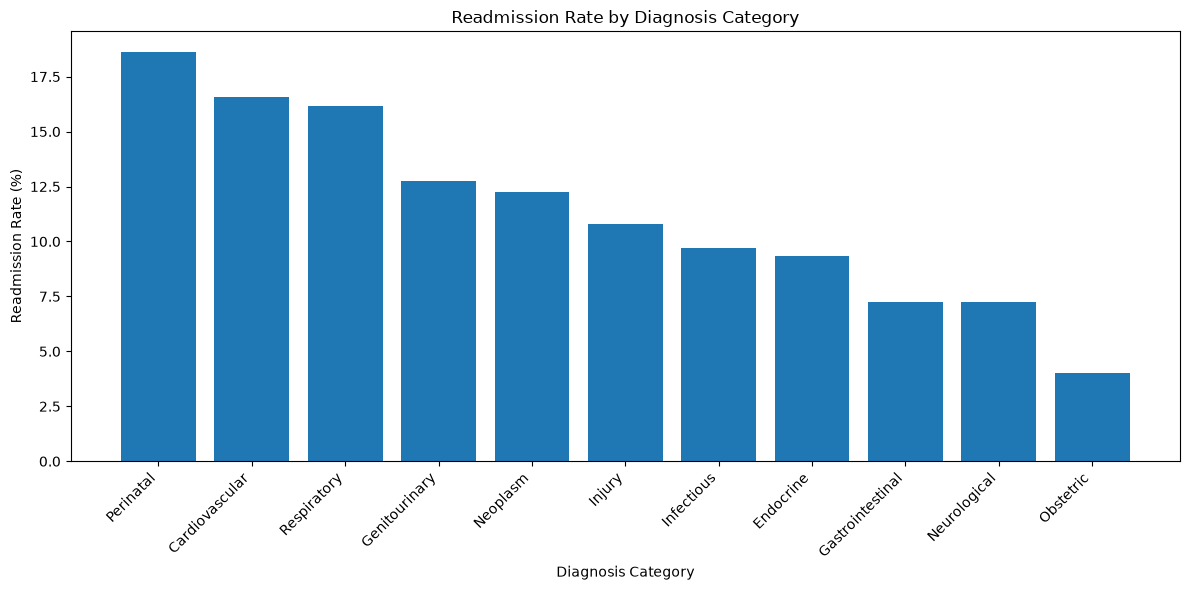

In [167]:
plt.figure(figsize=(12,6))

plt.bar(
    diagnosis_readmission["primary_diag_category"],
    diagnosis_readmission["Readmission_Rate"]
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Diagnosis Category")

plt.ylabel("Readmission Rate (%)")

plt.title("Readmission Rate by Diagnosis Category")

plt.tight_layout()

plt.show()

In [168]:
diagnosis_readmission.to_csv(
    "../powerbi/readmission_by_diagnosis.csv",
    index=False
)

print("Readmission by Diagnosis exported successfully.")

Readmission by Diagnosis exported successfully.


In [169]:
query = """
SELECT

    hospital_tier,

    COUNT(*) AS Total_Admissions,

    SUM(readmitted_30d) AS Readmitted_Patients,

    ROUND(
        AVG(readmitted_30d) * 100,
        2
    ) AS Readmission_Rate

FROM hospital_data

GROUP BY hospital_tier

ORDER BY Readmission_Rate DESC;
"""

tier_readmission = pd.read_sql_query(
    query,
    connection
)

tier_readmission

,hospital_tier,Total_Admissions,Readmitted_Patients,Readmission_Rate
0,tier2,54505,6502,11.93
1,tier1,29027,3444,11.86
2,tier3,36468,4264,11.69


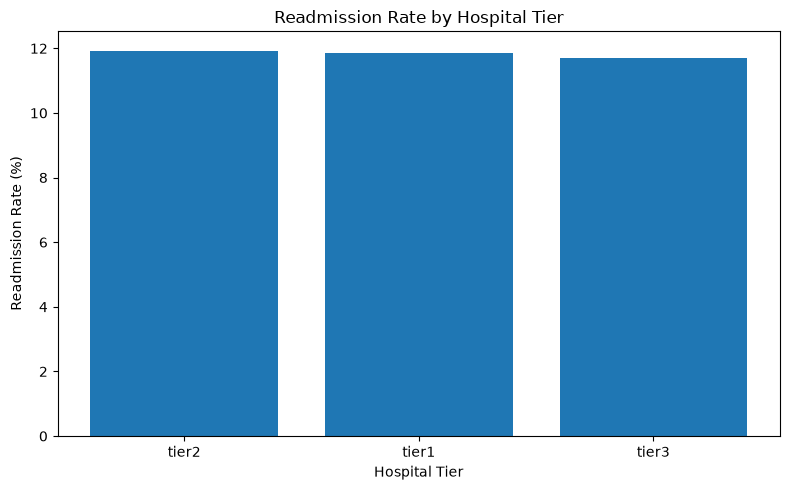

In [170]:
plt.figure(figsize=(8,5))

plt.bar(
    tier_readmission["hospital_tier"].astype(str),
    tier_readmission["Readmission_Rate"]
)

plt.xlabel("Hospital Tier")

plt.ylabel("Readmission Rate (%)")

plt.title("Readmission Rate by Hospital Tier")

plt.tight_layout()

plt.show()

In [171]:
tier_readmission.to_csv(
    "../powerbi/readmission_by_hospital_tier.csv",
    index=False
)

print("Readmission by Hospital Tier exported successfully.")

Readmission by Hospital Tier exported successfully.


In [172]:
query = """
SELECT

    insurance_type,

    COUNT(*) AS Total_Admissions,

    SUM(readmitted_30d) AS Readmitted_Patients,

    ROUND(
        AVG(readmitted_30d) * 100,
        2
    ) AS Readmission_Rate

FROM hospital_data

GROUP BY insurance_type

ORDER BY Readmission_Rate DESC;
"""

insurance_readmission = pd.read_sql_query(
    query,
    connection
)

insurance_readmission

,insurance_type,Total_Admissions,Readmitted_Patients,Readmission_Rate
0,Ayushman,36264,5047,13.92
1,ESI,19841,2411,12.15
2,Unknown,33987,3967,11.67
3,Private,29908,2785,9.31


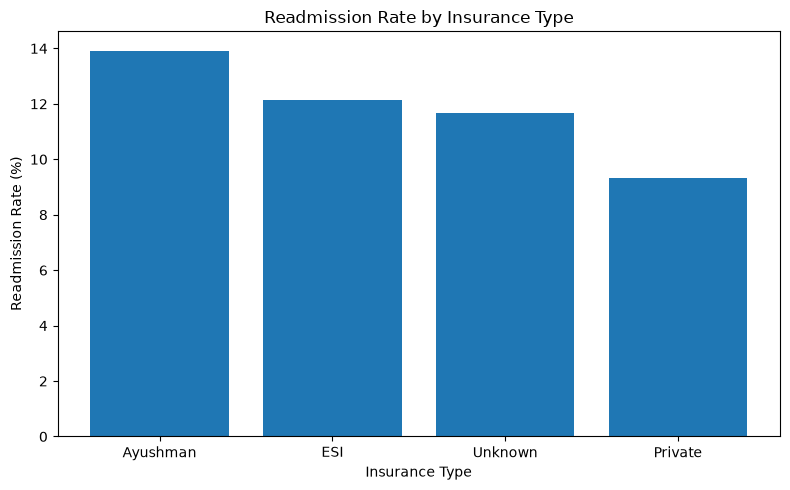

In [173]:
plt.figure(figsize=(8,5))

plt.bar(
    insurance_readmission["insurance_type"],
    insurance_readmission["Readmission_Rate"]
)

plt.xlabel("Insurance Type")

plt.ylabel("Readmission Rate (%)")

plt.title("Readmission Rate by Insurance Type")

plt.tight_layout()

plt.show()

In [174]:
insurance_readmission.to_csv(
    "../powerbi/readmission_by_insurance.csv",
    index=False
)

print("Readmission by Insurance exported successfully.")

Readmission by Insurance exported successfully.


In [175]:
query = """
SELECT

    ward_type,

    COUNT(*) AS Total_Admissions,

    SUM(readmitted_30d) AS Readmitted_Patients,

    ROUND(
        AVG(readmitted_30d) * 100,
        2
    ) AS Readmission_Rate

FROM hospital_data

GROUP BY ward_type

ORDER BY Readmission_Rate DESC;
"""

ward_readmission = pd.read_sql_query(
    query,
    connection
)

ward_readmission

,ward_type,Total_Admissions,Readmitted_Patients,Readmission_Rate
0,ICU,20833,4950,23.76
1,NICU,6492,1078,16.61
2,HDU,15907,2117,13.31
3,General,76768,6065,7.90


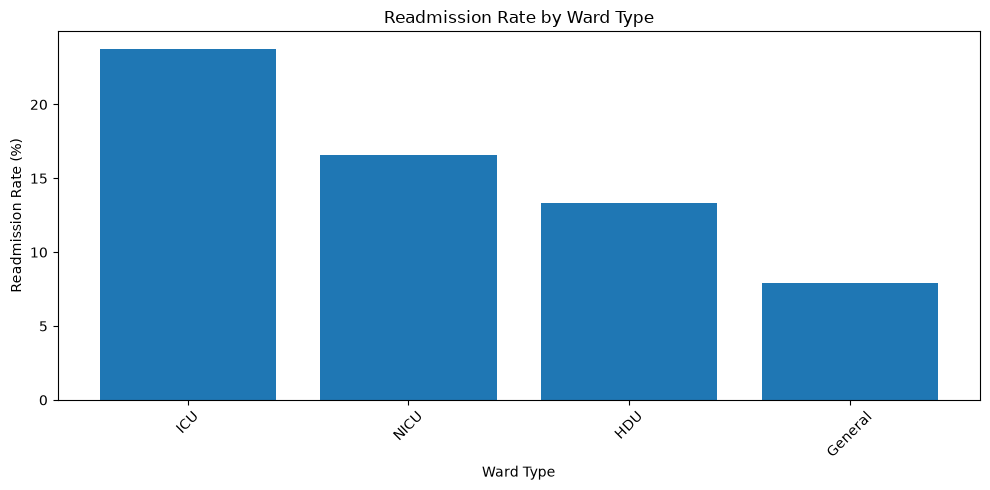

In [176]:
plt.figure(figsize=(10,5))

plt.bar(
    ward_readmission["ward_type"],
    ward_readmission["Readmission_Rate"]
)

plt.xticks(rotation=45)

plt.xlabel("Ward Type")

plt.ylabel("Readmission Rate (%)")

plt.title("Readmission Rate by Ward Type")

plt.tight_layout()

plt.show()

In [177]:
ward_readmission.to_csv(
    "../powerbi/readmission_by_ward.csv",
    index=False
)

print("Readmission by Ward exported successfully.")

Readmission by Ward exported successfully.


In [178]:
query = """
SELECT

    CASE

        WHEN age < 18 THEN 'Children'

        WHEN age BETWEEN 18 AND 39 THEN 'Young Adults'

        WHEN age BETWEEN 40 AND 59 THEN 'Middle Aged'

        WHEN age BETWEEN 60 AND 79 THEN 'Senior'

        ELSE 'Very Senior'

    END AS Age_Group,

    COUNT(*) AS Total_Admissions,

    SUM(readmitted_30d) AS Readmitted_Patients,

    ROUND(
        AVG(readmitted_30d) * 100,
        2
    ) AS Readmission_Rate

FROM hospital_data

GROUP BY Age_Group

ORDER BY Readmission_Rate DESC;
"""

age_readmission = pd.read_sql_query(
    query,
    connection
)

age_readmission

,Age_Group,Total_Admissions,Readmitted_Patients,Readmission_Rate
0,Very Senior,6734,1533,22.77
1,Senior,31242,5908,18.91
2,Middle Aged,46320,4644,10.03
3,Children,16060,989,6.16
4,Young Adults,19644,1136,5.78


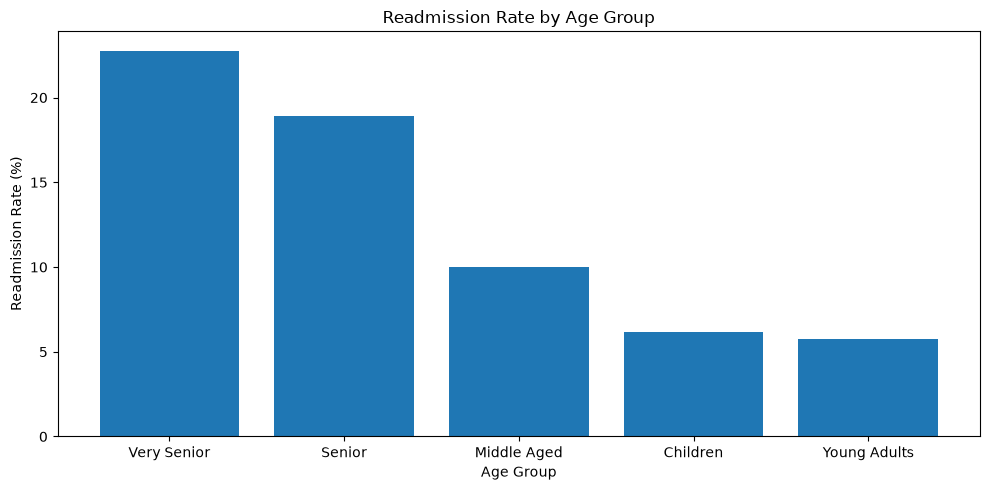

In [179]:
plt.figure(figsize=(10,5))

plt.bar(
    age_readmission["Age_Group"],
    age_readmission["Readmission_Rate"]
)

plt.xlabel("Age Group")

plt.ylabel("Readmission Rate (%)")

plt.title("Readmission Rate by Age Group")

plt.tight_layout()

plt.show()

In [180]:
age_readmission.to_csv(
    "../powerbi/readmission_by_age_group.csv",
    index=False
)

print("Readmission by Age Group exported successfully.")

Readmission by Age Group exported successfully.


In [181]:
query = """
SELECT

    season,

    COUNT(*) AS Total_Admissions,

    SUM(readmitted_30d) AS Readmitted_Patients,

    ROUND(
        AVG(readmitted_30d) * 100,
        2
    ) AS Readmission_Rate

FROM hospital_data

GROUP BY season

ORDER BY Readmission_Rate DESC;
"""

season_readmission = pd.read_sql_query(
    query,
    connection
)

season_readmission

,season,Total_Admissions,Readmitted_Patients,Readmission_Rate
0,Summer,30288,3603,11.90
1,Spring,30327,3600,11.87
2,Autumn,29819,3538,11.86
3,Winter,29566,3469,11.73


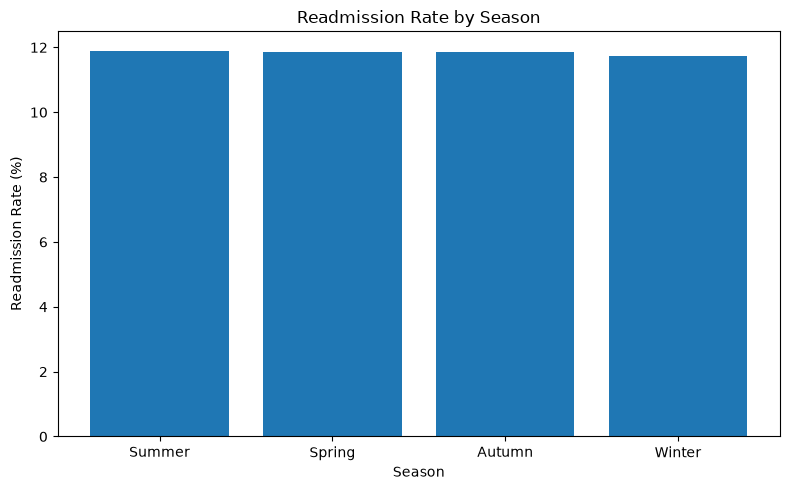

In [182]:
plt.figure(figsize=(8,5))

plt.bar(
    season_readmission["season"],
    season_readmission["Readmission_Rate"]
)

plt.xlabel("Season")

plt.ylabel("Readmission Rate (%)")

plt.title("Readmission Rate by Season")

plt.tight_layout()

plt.show()

In [183]:
season_readmission.to_csv(
    "../powerbi/readmission_by_season.csv",
    index=False
)

print("Readmission by Season exported successfully.")

Readmission by Season exported successfully.


In [184]:
query = """
SELECT

    CASE

        WHEN teaching = 1 THEN 'Teaching Hospital'

        ELSE 'Non-Teaching Hospital'

    END AS Hospital_Type,

    COUNT(*) AS Total_Admissions,

    SUM(readmitted_30d) AS Readmitted_Patients,

    ROUND(
        AVG(readmitted_30d) * 100,
        2
    ) AS Readmission_Rate

FROM hospital_data

GROUP BY Hospital_Type

ORDER BY Readmission_Rate DESC;
"""

teaching_readmission = pd.read_sql_query(
    query,
    connection
)

teaching_readmission

,Hospital_Type,Total_Admissions,Readmitted_Patients,Readmission_Rate
0,Teaching Hospital,69087,8261,11.96
1,Non-Teaching Hospital,50913,5949,11.68


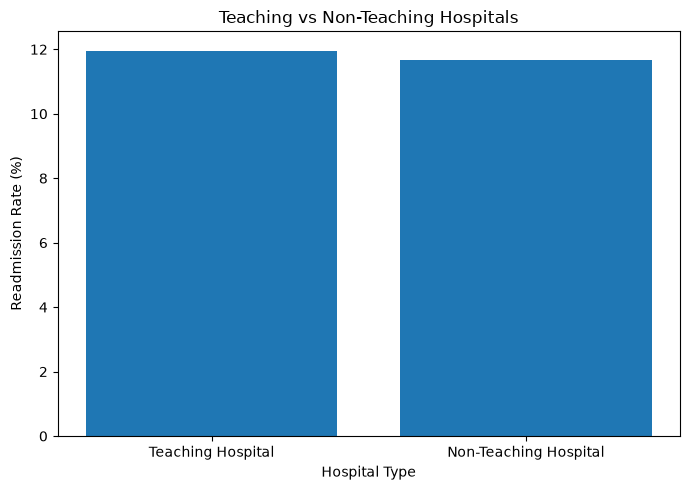

In [185]:
plt.figure(figsize=(7,5))

plt.bar(
    teaching_readmission["Hospital_Type"],
    teaching_readmission["Readmission_Rate"]
)

plt.xlabel("Hospital Type")

plt.ylabel("Readmission Rate (%)")

plt.title("Teaching vs Non-Teaching Hospitals")

plt.tight_layout()

plt.show()

In [186]:
teaching_readmission.to_csv(
    "../powerbi/readmission_by_teaching.csv",
    index=False
)

print("Teaching Hospital Analysis exported successfully.")

Teaching Hospital Analysis exported successfully.


In [187]:
query = """
SELECT

    CASE

        WHEN weekend_admission = 1 THEN 'Weekend'

        ELSE 'Weekday'

    END AS Admission_Type,

    COUNT(*) AS Total_Admissions,

    SUM(readmitted_30d) AS Readmitted_Patients,

    ROUND(
        AVG(readmitted_30d) * 100,
        2
    ) AS Readmission_Rate

FROM hospital_data

GROUP BY Admission_Type

ORDER BY Readmission_Rate DESC;
"""

weekend_readmission = pd.read_sql_query(
    query,
    connection
)

weekend_readmission

,Admission_Type,Total_Admissions,Readmitted_Patients,Readmission_Rate
0,Weekday,85622,10182,11.89
1,Weekend,34378,4028,11.72


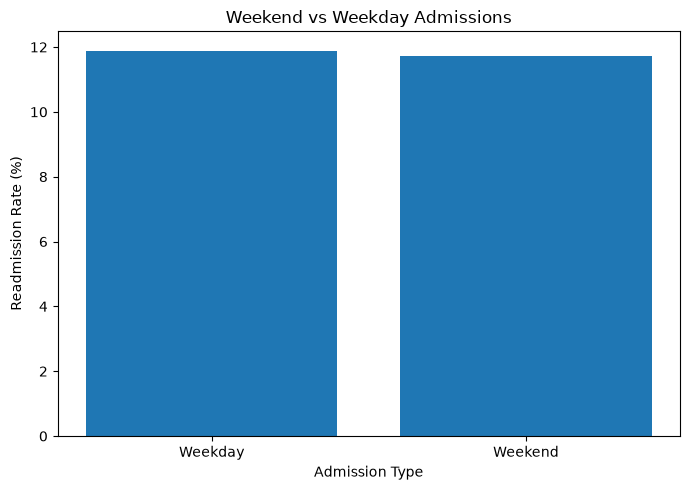

In [188]:
plt.figure(figsize=(7,5))

plt.bar(
    weekend_readmission["Admission_Type"],
    weekend_readmission["Readmission_Rate"]
)

plt.xlabel("Admission Type")

plt.ylabel("Readmission Rate (%)")

plt.title("Weekend vs Weekday Admissions")

plt.tight_layout()

plt.show()

In [189]:
weekend_readmission.to_csv(
    "../powerbi/readmission_weekend_vs_weekday.csv",
    index=False
)

print("Weekend Admission Analysis exported successfully.")

Weekend Admission Analysis exported successfully.


In [190]:
query = """
SELECT

    hospital_name,

    COUNT(*) AS Total_Admissions,

    ROUND(
        AVG(los_days),
        2
    ) AS Average_LOS

FROM hospital_data

GROUP BY hospital_name

ORDER BY Average_LOS DESC;
"""

hospital_los = pd.read_sql_query(
    query,
    connection
)

hospital_los.head(10)

,hospital_name,Total_Admissions,Average_LOS
0,Government General Hospital Uttar Pradesh,3640,7.00
1,Government General Hospital Haryana,3650,7.00
2,Government General Hospital Gujarat,3596,6.97
3,District Hospital Kerala,3617,6.96
4,District Hospital Bihar,7439,6.96
5,Government General Hospital Punjab,3612,6.95
6,Government General Hospital Karnataka,3653,6.95
7,Government General Hospital Tamil Nadu,3660,6.94
8,Government General Hospital Kerala,3581,6.91
9,Apollo/Manipal (Private) Telangana,3720,6.90


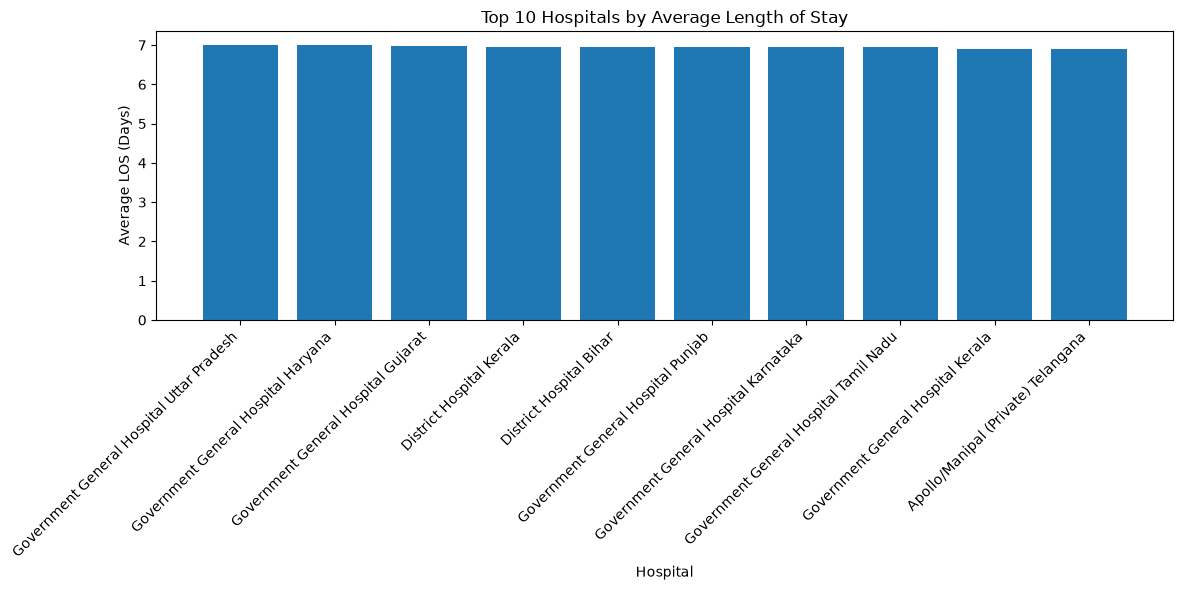

In [191]:
top10_los = hospital_los.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10_los["hospital_name"],
    top10_los["Average_LOS"]
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Hospital")

plt.ylabel("Average LOS (Days)")

plt.title("Top 10 Hospitals by Average Length of Stay")

plt.tight_layout()

plt.show()

In [192]:
hospital_los.to_csv(
    "../powerbi/hospital_los.csv",
    index=False
)

print("Hospital LOS exported successfully.")

Hospital LOS exported successfully.


In [193]:
query = """
SELECT

    ward_type,

    ROUND(
        AVG(los_days),
        2
    ) AS Average_LOS,

    COUNT(*) AS Total_Admissions

FROM hospital_data

GROUP BY ward_type

ORDER BY Average_LOS DESC;
"""

ward_los = pd.read_sql_query(
    query,
    connection
)

ward_los

,ward_type,Average_LOS,Total_Admissions
0,NICU,16.61,6492
1,ICU,12.91,20833
2,HDU,6.26,15907
3,General,4.51,76768


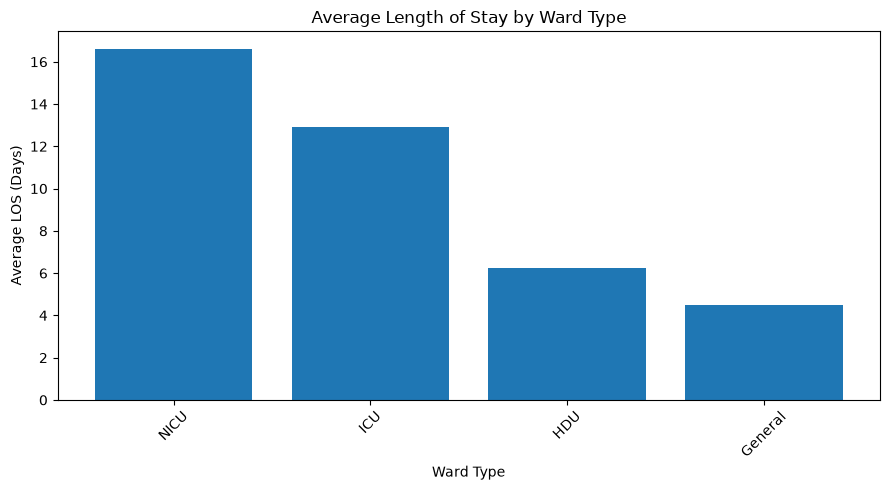

In [194]:
plt.figure(figsize=(9,5))

plt.bar(
    ward_los["ward_type"],
    ward_los["Average_LOS"]
)

plt.xticks(rotation=45)

plt.xlabel("Ward Type")

plt.ylabel("Average LOS (Days)")

plt.title("Average Length of Stay by Ward Type")

plt.tight_layout()

plt.show()

In [195]:
ward_los.to_csv(
    "../powerbi/ward_los.csv",
    index=False
)

print("Ward LOS exported successfully.")

Ward LOS exported successfully.


In [196]:
query = """
SELECT

    hospital_name,

    MAX(beds) AS Total_Beds,

    COUNT(*) AS Total_Admissions,

    ROUND(
        COUNT(*) * 1.0 / MAX(beds),
        2
    ) AS Admissions_Per_Bed

FROM hospital_data

GROUP BY hospital_name

ORDER BY Admissions_Per_Bed DESC;
"""

bed_analysis = pd.read_sql_query(
    query,
    connection
)

bed_analysis.head(10)

,hospital_name,Total_Beds,Total_Admissions,Admissions_Per_Bed
0,District Hospital Kerala,61,3617,59.30
1,District Hospital Madhya Pradesh,67,3646,54.42
2,District Hospital Bihar,142,7439,52.39
3,District Hospital Gujarat,70,3631,51.87
4,District Hospital Odisha,146,7125,48.80
5,District Hospital Uttar Pradesh,191,7369,38.58
6,District Hospital Rajasthan,197,3641,18.48
7,Government General Hospital Gujarat,230,3596,15.63
8,Apollo/Manipal (Private) Andhra Pradesh,986,14497,14.70
9,Government General Hospital Karnataka,304,3653,12.02


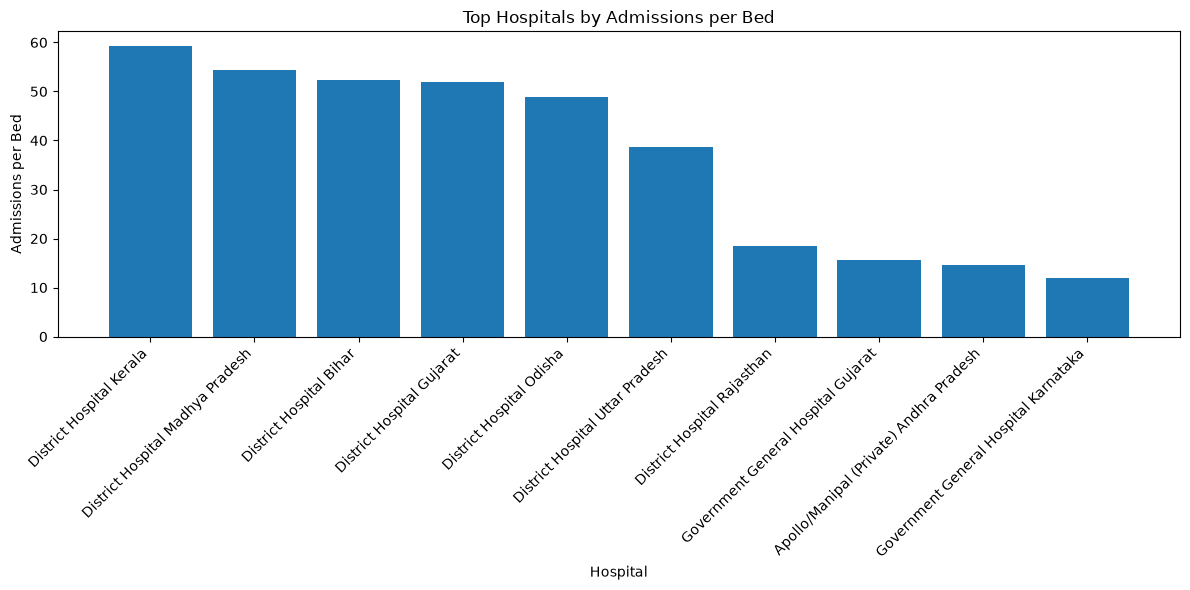

In [197]:
top10_beds = bed_analysis.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10_beds["hospital_name"],
    top10_beds["Admissions_Per_Bed"]
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Hospital")

plt.ylabel("Admissions per Bed")

plt.title("Top Hospitals by Admissions per Bed")

plt.tight_layout()

plt.show()

In [198]:
bed_analysis.to_csv(
    "../powerbi/bed_analysis.csv",
    index=False
)

print("Bed Analysis exported successfully.")

Bed Analysis exported successfully.


In [199]:
query = """
SELECT

    CASE

        WHEN large_hospital = 1 THEN 'Large Hospital'

        ELSE 'Small / Medium Hospital'

    END AS Hospital_Size,

    COUNT(*) AS Total_Admissions,

    ROUND(
        AVG(los_days),
        2
    ) AS Average_LOS,

    ROUND(
        AVG(total_cost_inr),
        2
    ) AS Average_Cost,

    ROUND(
        AVG(readmitted_30d) * 100,
        2
    ) AS Readmission_Rate

FROM hospital_data

GROUP BY Hospital_Size;
"""

hospital_size = pd.read_sql_query(
    query,
    connection
)

hospital_size

,Hospital_Size,Total_Admissions,Average_LOS,Average_Cost,Readmission_Rate
0,Large Hospital,61698,6.86,135274.19,12.00
1,Small / Medium Hospital,58302,6.84,53984.38,11.68


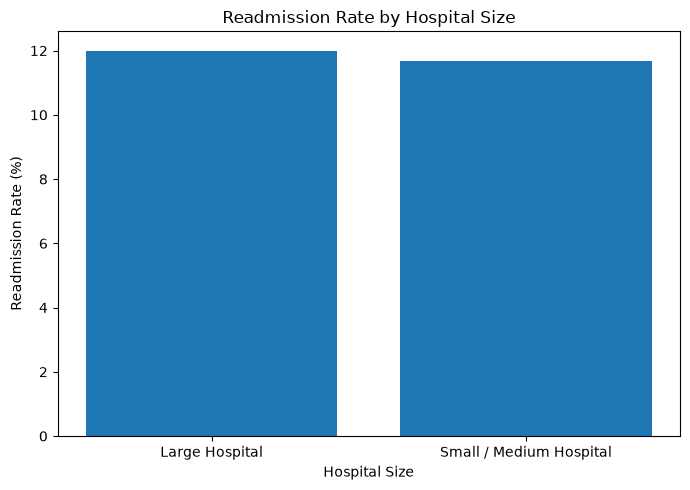

In [200]:
plt.figure(figsize=(7,5))

plt.bar(
    hospital_size["Hospital_Size"],
    hospital_size["Readmission_Rate"]
)

plt.xlabel("Hospital Size")

plt.ylabel("Readmission Rate (%)")

plt.title("Readmission Rate by Hospital Size")

plt.tight_layout()

plt.show()

In [201]:
hospital_size.to_csv(
    "../powerbi/hospital_size_analysis.csv",
    index=False
)

print("Hospital Size Analysis exported successfully.")

Hospital Size Analysis exported successfully.


In [202]:
df.to_csv(
    "../powerbi/dashboard_data.csv",
    index=False
)

print("Dashboard dataset exported successfully.")

Dashboard dataset exported successfully.
